# **Eventos Adversos en medicamentos de la FDA**

https://www.kaggle.com/datasets/mdmahfuzsumon/hidden-drug-risks-revealed?resource=download

Csv utilizado:

 FDA Drug Adverse Events Dataset Q4-2025-P33.csv

# Diccionario de datos

report_id Identificador único para cada informe de evento adverso

country País donde se envió el informe

occur_country País donde ocurrió el evento adverso

report_type Tipo de informe (p. ej., espontáneo, bibliográfico)

serious Indica si el caso es grave (1 = Sí, 0 = No)

death Indica si el evento resultó en la muerte

life_threatening Indica si el evento fue potencialmente mortal

hospitalization Indica si hubo hospitalización

disabling Indica si se produjo alguna discapacidad

receive_date Fecha de recepción del informe (AAAAMMDD)

age Edad del paciente

age_unit Unidad de edad (p. ej., años, meses)

gender Sexo del paciente (1 = Masculino, 2 = Femenino)

weight Peso del paciente (si está disponible)

drug Nombre del medicamento involucrado

reaction Descripción de la reacción adversa

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import seaborn as sns

!pip install category_encoders

import category_encoders as ce

df = pd.read_csv('/content/drive/MyDrive/Evaluacion 1 Kevin/Copia de FDA Drug Adverse Events Dataset Q4-2025-P33.csv')
pd.options.display.max_columns = None
pd.options.display.max_rows = 9999
pd.options.display.max_colwidth = None

# **Fase 1: Entendiendo el negocio y explorando datos**

Este conjunto de datos contiene informes de eventos adversos recolectados por la FDA. Lo elegimos porque presenta una buena mezcla de variables categóricas (país, medicamento, reacción) y numéricas (edad, peso). Es ideal para la continuidad del semestre ya que permite predecir la gravedad de un caso (Clasificación) o analizar tendencias de dosis y edad (Regresión), cumpliendo con el requisito de ser un dataset amplio y complejo.

In [2]:
df.head(5)

,report_id,country,occur_country,report_type,serious,death,life_threatening,hospitalization,disabling,receive_date,age,age_unit,gender,weight,drug,reaction
0,26016170,US,US,1,2.0,2.0,2.0,2.0,2.0,20251110,42.0,801.0,1.0,NaN,DUPIXENT,abdominal pain
1,26017452,NP,NP,1,1.0,1.0,2.0,1.0,2.0,20251110,51.0,801.0,1.0,NaN,METHOTREXATE,toxicity to various agents
2,26017586,US,US,1,2.0,2.0,2.0,2.0,2.0,20251110,NaN,NaN,2.0,NaN,PEPCID COMPLETE,exposure during pregnancy
3,26018910,SG,SG,1,1.0,2.0,2.0,2.0,2.0,20251110,62.0,801.0,2.0,NaN,PACLITAXEL,drug ineffective
4,26018949,EU,EU,3,1.0,2.0,2.0,2.0,2.0,20251110,NaN,NaN,NaN,NaN,DULOXETINE,drug interaction


In [3]:
#Valores nulos y tipos de datos

print("\nInformación de columnas:")
df.info()


Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1287 entries, 0 to 1286
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   report_id         1287 non-null   int64  
 1   country           1287 non-null   object 
 2   occur_country     1208 non-null   object 
 3   report_type       1287 non-null   int64  
 4   serious           1267 non-null   float64
 5   death             1233 non-null   float64
 6   life_threatening  1230 non-null   float64
 7   hospitalization   1242 non-null   float64
 8   disabling         1231 non-null   float64
 9   receive_date      1287 non-null   int64  
 10  age               880 non-null    float64
 11  age_unit          881 non-null    float64
 12  gender            1072 non-null   float64
 13  weight            295 non-null    float64
 14  drug              1287 non-null   object 
 15  reaction          1287 non-null   object 
dtypes: float64(9), i

In [4]:
print("\nValores nulos:")
print(df.isna().sum())


Valores nulos:
report_id             0
country               0
occur_country        79
report_type           0
serious              20
death                54
life_threatening     57
hospitalization      45
disabling            56
receive_date          0
age                 407
age_unit            406
gender              215
weight              992
drug                  0
reaction              0
dtype: int64


In [5]:
#Contenido del dataset
print(df.shape) #hacer graficos

(1287, 16)


Podemos ver que el dataset tiene mas de 900 nulos en una fila tan importante como el peso por ende buscaremos la mejor forma de imputacion posible para tratar con esos nulos

# Fase 2: Entendimiento de los datos

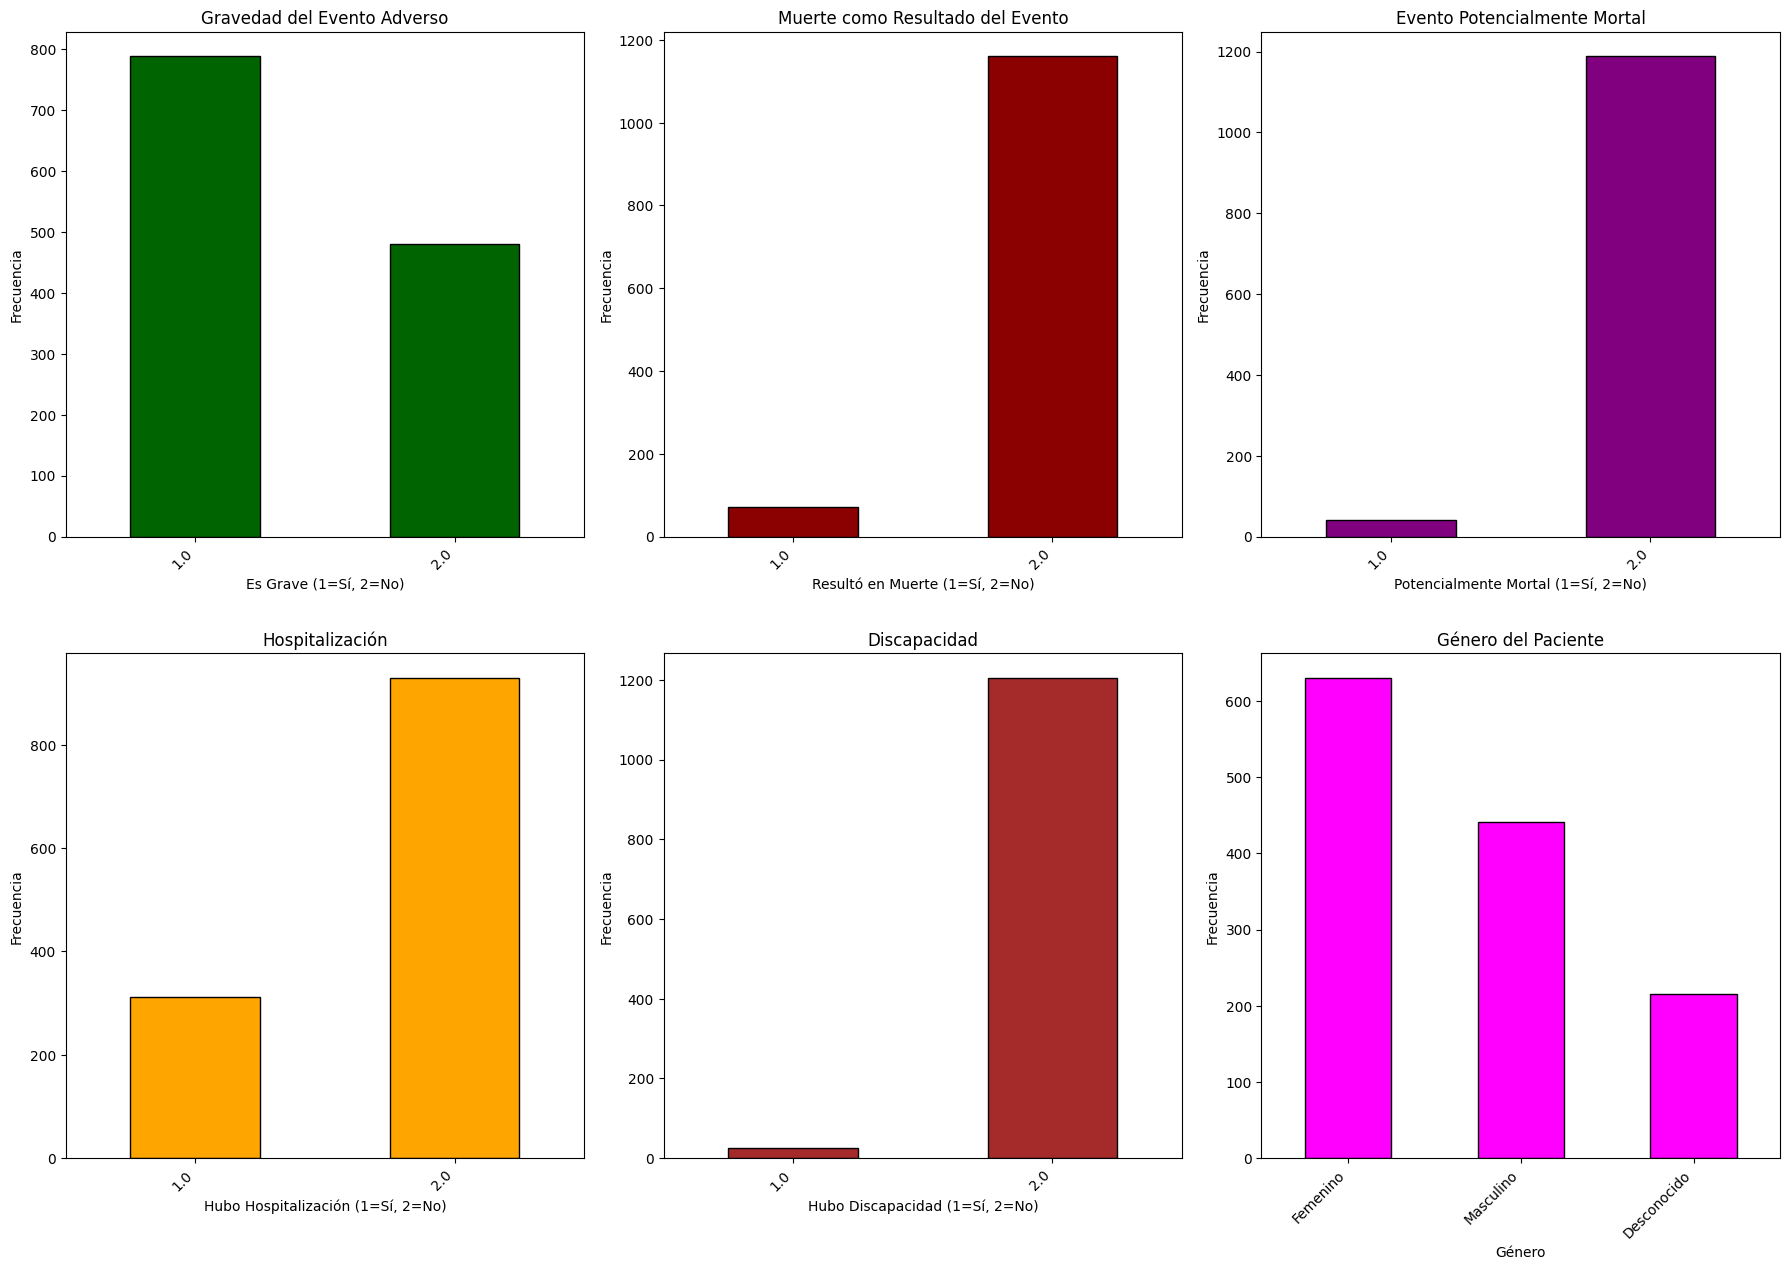

In [6]:
# De los datos que no son nulos haremos un analisis preeliminar de variables categoricas

# Lista de columnas categóricas a graficar
categorical_cols = [
    ('serious', 'Gravedad del Evento Adverso', 'Es Grave (1=Sí, 2=No)', 'darkgreen'),
    ('death', 'Muerte como Resultado del Evento', 'Resultó en Muerte (1=Sí, 2=No)', 'darkred'),
    ('life_threatening', 'Evento Potencialmente Mortal', 'Potencialmente Mortal (1=Sí, 2=No)', 'purple'),
    ('hospitalization', 'Hospitalización', 'Hubo Hospitalización (1=Sí, 2=No)', 'orange'),
    ('disabling', 'Discapacidad', 'Hubo Discapacidad (1=Sí, 2=No)', 'brown'),
    ('gender', 'Género del Paciente', 'Género', 'magenta')
]

# Crear la figura y la cuadrícula de subplots (3x3)
fig, axes = plt.subplots(3, 3, figsize=(18, 18)) # Ajustar a 3x3 y aumentar figsize
axes = axes.flatten() # Aplanar el array de axes para fácil iteración

for i, (col, title, xlabel, color) in enumerate(categorical_cols):
    ax = axes[i]

    if col == 'gender':
        gender_counts = df['gender'].fillna('Desconocido').map({1.0: 'Masculino', 2.0: 'Femenino', 'Desconocido': 'Desconocido'}).value_counts()
        gender_counts.plot(kind='bar', color=color, edgecolor='black', ax=ax)
    else:
        df[col].value_counts().sort_index().plot(kind='bar', color=color, edgecolor='black', ax=ax)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frecuencia')
    # If horizontal alignment is still needed, it should be set on the tick labels explicitly:
    plt.setp(ax.get_xticklabels(), ha='right', rotation=45)

# Ocultar los ejes de los subplots vacíos
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

De esta forma podemos ver la distribucion de algunas categoricas en estilo "one hot", podemos fijarnos que el dataset esas variables "one hot" son de 1 y 2 y no 0 y 1, lo que puede influenciar a futuro para clasificaciones binarias

In [7]:
df['country'].unique()

array(['US', 'NP', 'SG', 'EU', 'CA', 'JP', 'CN', 'KR', 'GB', 'PR', 'MX',
       'AU', 'BR', 'ZA', 'IN', 'ID', 'CH', 'PH', 'RU', 'CO', 'DZ', 'TH',
       'TW', 'NZ', 'AR', 'AE', 'NG', 'VE', 'EG', 'BA', 'VN', 'IL', 'CR',
       'CL'], dtype=object)

In [8]:
df['drug'].unique()

array(['DUPIXENT', 'METHOTREXATE', 'PEPCID COMPLETE', 'PACLITAXEL',
       'DULOXETINE', 'DOCETAXEL', 'POLYETHYLENE GLYCOL 3350',
       'VEDOLIZUMAB', 'BEVACIZUMAB', 'SKYRIZI', 'ABIRATERONE ACETATE',
       'WEGOVY', 'NEULASTA', 'REMODULIN', 'LETROZOLE', 'MINOCYCLINE',
       'DEXAMETHASONE', 'RITUXIMAB', 'AXICABTAGENE CILOLEUCEL',
       'FIRDAPSE', 'TRULICITY', 'METHOTREXATE SODIUM', 'ACETAMINOPHEN',
       'VONJO', 'RIVAROXABAN', 'VOLTAREN', 'PLUVICTO', 'NUPLAZID',
       'TISLELIZUMAB', 'ISONIAZID', 'LENALIDOMIDE', 'CARBOPLATIN',
       'CREON', 'CYCLOSPORINE', 'HUMAN IMMUNOGLOBULIN G', 'LOSARTAN',
       'SIROLIMUS', 'AYVAKIT', 'CORTICOTROPIN', 'SPRAVATO',
       'TRELEGY ELLIPTA', 'GEMTESA', 'ORGOVYX', 'OPDIVO', 'OCREVUS',
       'BUPRENORPHINE', 'TORIPALIMAB', 'MIRTAZAPINE', 'ESOMEPRAZOLE',
       'VENCLEXTA', 'XGEVA', 'BENRALIZUMAB', 'CITALOPRAM', 'ORENCIA',
       'TIGECYCLINE', 'FINASTERIDE', 'IXAZOMIB', 'IBUPROFEN',
       'MYCOPHENOLATE MOFETIL', 'RISPERIDONE', 'AZATHIOPRI

Tenemos demasiadas categorias aqui lo mejor para aplicar un encoder pueda ser por clase o binario

In [9]:
#Variables Numericas

df.describe().round(2)

,report_id,report_type,serious,death,life_threatening,hospitalization,disabling,receive_date,age,age_unit,gender,weight
count,1287.00,1287.00,1267.00,1233.00,1230.00,1242.00,1231.00,1287.00,880.00,881.00,1072.00,295.00
mean,25423623.71,1.21,1.38,1.94,1.97,1.75,1.98,20247726.19,52.50,801.00,1.59,76.85
std,1519859.27,0.44,0.49,0.23,0.18,0.43,0.14,9546.39,21.94,0.16,0.49,27.80
min,14520544.00,1.00,1.00,1.00,1.00,1.00,1.00,20180212.00,0.00,800.00,1.00,1.88
25%,25652722.50,1.00,1.00,2.00,2.00,1.00,2.00,20250807.00,36.00,801.00,1.00,59.04
50%,25981881.00,1.00,1.00,2.00,2.00,2.00,2.00,20251031.00,57.00,801.00,2.00,75.00
75%,26086189.50,1.00,2.00,2.00,2.00,2.00,2.00,20251125.00,70.00,801.00,2.00,90.70
max,26216860.00,3.00,2.00,2.00,2.00,2.00,2.00,20251231.00,100.00,804.00,2.00,220.00


## **Trabajo con nulos**

Debido a que la mayoria de nulos se centralizan en las variables numericas estos estidisticos se encuentran sesgados, se realizara un trabajo a los nulos para ver la correlacion

Primero imputamos las variables categóricas y binarias con menos nulos. Estas servirán como predictores para la edad y el peso.

serious, death, life_threatening, hospitalization, disabling: Son los resultados del evento. Siendo datos de la FDA, la Moda es el camino más seguro para no inventar gravedades que no existen.

gender (215 nulos): Al no ser mas de 50% de nulos, la moda es aceptable, pero lo ideal es imputar antes de ir a por el peso, ya que el peso depende mucho del género.

occur_country (79 nulos): Técnica de "Negocio": Si el país de ocurrencia es nulo, lo más probable es que sea el mismo que el país de reporte (country).

In [10]:
# Creamos df2 como una copia profunda para no afectar el dataset original
df2 = df.copy()
print("Copia df2 creada. Listos para iniciar la limpieza")

Copia df2 creada. Listos para iniciar la limpieza


In [11]:
# Definimos las columnas que imputaremos por el valor más frecuente (Moda)
cols_binarias = ['serious', 'death', 'life_threatening', 'hospitalization', 'disabling', 'gender', 'age_unit']

for col in cols_binarias:

    df2[col] = df2[col].fillna(df2[col].mode()[0])

# 2. Lógica de negocio para el país de ocurrencia
# Si no se especifica, asumimos que es el mismo país que reporta
df2['occur_country'] = df2['occur_country'].fillna(df2['country'])

print("Fase 1 completada: Variables categóricas y lógicas imputadas")
df2[['serious', 'death', 'life_threatening', 'hospitalization', 'disabling', 'gender', 'age_unit']].isnull().sum()

Fase 1 completada: Variables categóricas y lógicas imputadas


,0
serious,0
death,0
life_threatening,0
hospitalization,0
disabling,0
gender,0
age_unit,0


Imputamos por la media debido a que estas variables son fijas 1 o 2, tambien age_unit es categorico debido a que son codigos donde se calcula la edad en decadas, años, meses y dias

In [12]:
# Estandarizamos la edad con age_unit para luego hacer una regresion mas precisa
def estandarizar_final(row):
    unit = row['age_unit']
    val = row['age']
    if unit == 800: return val * 10
    if unit == 802: return val / 12
    if unit == 804: return val / 365
    return val

# 2. Aplicamos la transformación
df2['age'] = df2.apply(estandarizar_final, axis=1)


print("Dataset de modelo estandarizado")

Dataset de modelo estandarizado


Estandarizamos ya que pueden haber ciertas contradicciones en edad y peso si no consideramos age_unit ya que una persona con age 4 con unit de 800 quiere decir que tiene 40 años y no 4

In [13]:
# Seleccionamos las columnas numéricas que servirán de base para la predicción
cols_modelo = ['age', 'weight', 'gender', 'serious', 'hospitalization', 'death']

# IterativeImputer usa regresión por defecto
imputer = IterativeImputer(random_state=42, max_iter=10)

# Aplicamos la transformación solo a las columnas de interés
df2[cols_modelo] = imputer.fit_transform(df2[cols_modelo])

print("Fase 2 completada: Edad y Peso imputados mediante regresión")

Fase 2 completada: Edad y Peso imputados mediante regresión


IterativeImputer es una técnica de imputación multivariada. A diferencia de métodos simples como reemplazar nulos con la media o la moda, este imputador modela cada característica con valores faltantes como una función de otras características, y usa ese modelo para estimar los valores faltantes.

In [14]:
#Redondeamos los valores para no tener numeros inconclusos en edad y
#no tener muchos decimales en los pesos

df2['weight'] = df2['weight'].round(2)
df2['age'] = df2['age'].round(3)
df2.head(10)

,report_id,country,occur_country,report_type,serious,death,life_threatening,hospitalization,disabling,receive_date,age,age_unit,gender,weight,drug,reaction
0,26016170,US,US,1,2.0,2.0,2.0,2.0,2.0,20251110,42.000,801.0,1.0,71.91,DUPIXENT,abdominal pain
1,26017452,NP,NP,1,1.0,1.0,2.0,1.0,2.0,20251110,51.000,801.0,1.0,74.99,METHOTREXATE,toxicity to various agents
2,26017586,US,US,1,2.0,2.0,2.0,2.0,2.0,20251110,49.062,801.0,2.0,74.30,PEPCID COMPLETE,exposure during pregnancy
3,26018910,SG,SG,1,1.0,2.0,2.0,2.0,2.0,20251110,62.000,801.0,2.0,78.76,PACLITAXEL,drug ineffective
4,26018949,EU,EU,3,1.0,2.0,2.0,2.0,2.0,20251110,53.763,801.0,2.0,75.89,DULOXETINE,drug interaction
5,26019625,US,US,1,1.0,2.0,2.0,2.0,2.0,20251110,67.000,801.0,1.0,80.59,DOCETAXEL,osteoporosis
6,26019988,US,US,1,2.0,2.0,2.0,2.0,2.0,20251110,49.062,801.0,2.0,74.30,POLYETHYLENE GLYCOL 3350,incorrect product administration duration
7,25942883,CA,CA,2,1.0,2.0,2.0,2.0,2.0,20251021,46.000,801.0,1.0,73.25,VEDOLIZUMAB,colitis ulcerative
8,25942964,JP,JP,1,1.0,1.0,2.0,2.0,2.0,20251021,78.000,801.0,1.0,84.43,BEVACIZUMAB,vascular stent thrombosis
9,25943989,US,US,1,2.0,2.0,2.0,2.0,2.0,20251021,49.062,801.0,2.0,74.30,SKYRIZI,swelling of eyelid


## **Estadisticos basicos y distribucion de los valores**

In [15]:
df2.describe().round(2)

,report_id,report_type,serious,death,life_threatening,hospitalization,disabling,receive_date,age,age_unit,gender,weight
count,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00,1287.00
mean,25423623.71,1.21,1.37,1.94,1.97,1.76,1.98,20247726.19,52.70,801.00,1.66,75.56
std,1519859.27,0.44,0.48,0.23,0.18,0.43,0.14,9546.39,18.28,0.13,0.47,14.35
min,14520544.00,1.00,1.00,1.00,1.00,1.00,1.00,20180212.00,0.00,800.00,1.00,1.88
25%,25652722.50,1.00,1.00,2.00,2.00,2.00,2.00,20250807.00,45.76,801.00,1.00,70.73
50%,25981881.00,1.00,1.00,2.00,2.00,2.00,2.00,20251031.00,53.76,801.00,2.00,75.89
75%,26086189.50,1.00,2.00,2.00,2.00,2.00,2.00,20251125.00,65.00,801.00,2.00,80.16
max,26216860.00,3.00,2.00,2.00,2.00,2.00,2.00,20251231.00,100.00,804.00,2.00,220.00


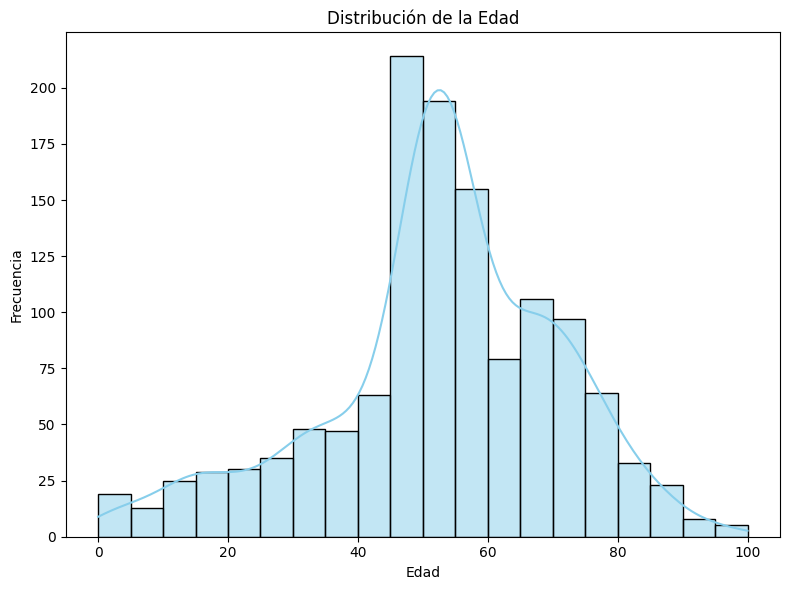

In [16]:
# Histograma para la edad
plt.figure(figsize=(8, 6))
sns.histplot(df2['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de la Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

La mayoria de casos de eventos adversos con farmacos son con personas entre 40 a 60 años. Esta distribucion es bimodal debido a que existen picos en rango etario de 45 a 80 años

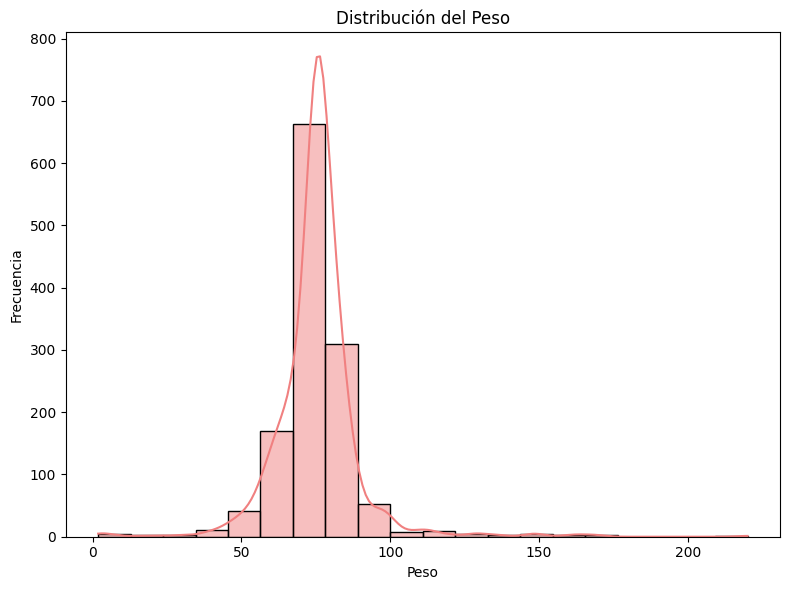

In [17]:
# Histograma para el peso
plt.figure(figsize=(8, 6))
sns.histplot(df2['weight'], bins=20, kde=True, color='lightcoral')
plt.title('Distribución del Peso')
plt.xlabel('Peso')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

La distribución del peso (weight) muestra un comportamiento cercano a la normalidad, con una media concentrada en el rango de los 75 kg. A diferencia de la edad, que es bimodal, el peso es una variable más homogénea en este dataset. Esto sugiere que, para los eventos adversos analizados, el peso corporal actúa como una variable de control estable, permitiendo que el modelo se enfoque en otras variables más dispersas como la dosis o el tipo de fármaco.

## Trabajo con outliers

Necesitamos filtrar datos para ver si hay valores atipicos, pesos muy altos para edades bajas o edad baja con pesos muy altos

In [18]:
# Filtro para detectar edades > 2 años con pesos imposibles (< 10kg)
incoherentes = df2[(df2['age'] >= 2) & (df2['weight'] < 10)]

print(f"Se encontraron {len(incoherentes)} casos imposibles:")
display(incoherentes[['report_id', 'age', 'weight', 'drug', 'reaction']])

Se encontraron 2 casos imposibles:


,report_id,age,weight,drug,reaction
90,25974459,13.900,1.88,METOPROLOL,bradycardia neonatal
1286,25237383,12.109,2.49,GENTAMICIN,neonatal respiratory distress syndrome


Este filtro suele ser exacto ya que se calculo la edad junto a su unit por ende realmente tienen 14 y 12 añoos respectivamente

In [19]:
pesos_altos_ninos = df2[(df2['age'] <= 12) & (df2['weight'] > 40)]

print(f"Se detectaron {len(pesos_altos_ninos)} niños con pesos exageradamente altos.")
display(pesos_altos_ninos[['age','age_unit', 'weight', 'drug', 'reaction']])

Se detectaron 34 niños con pesos exageradamente altos.


,age,age_unit,weight,drug,reaction
33,9.000,801.0,60.31,DUPIXENT,breast mass
115,8.000,801.0,59.90,MYCOPHENOLATE MOFETIL,lymphadenitis
128,4.000,801.0,58.64,DUPIXENT,dry skin
216,2.000,801.0,57.94,DUPIXENT,rash macular
292,9.000,801.0,60.25,DUPIXENT,suicidal ideation
355,0.333,802.0,57.30,NITROGLYCERIN,drug ineffective
360,0.833,802.0,57.40,VALPROIC ACID,drug resistance
369,6.000,801.0,59.28,TEDUGLUTIDE,gastrointestinal anastomotic stenosis
381,3.000,801.0,58.16,LEVETIRACETAM,apnoea
526,11.000,801.0,61.03,CYCLOSPORINE,skin graft rejection


Estos pueden ser errores dados por la imputacion de pesos debido a la gran cantidad de nulos que teniamos para realizar una regresion lineal, sin embargo es mejor que tener 400 nulos y una cantidad aceptable de filas a eliminar

Vamos a eliminar estos "outliers"

In [20]:
# Definimos la máscara de limpieza basada en tus filtros
outliers = (
    ((df2['age'] <= 12) & (df2['weight'] > 40)) |  # Niños muy pesados (error de imputación)
    ((df2['age'] >= 5) & (df2['weight'] < 10))     # Niños grandes con peso de recién nacido
)


total_borrados = len(df2[outliers])

#Limpiamos df2
df2 = df2.drop(df2[outliers].index)

print(f"¡Limpieza ejecutada! Se eliminaron {total_borrados} registros inconsistentes.")
print("Filas restantes en el dataset: ", df2.shape)

¡Limpieza ejecutada! Se eliminaron 36 registros inconsistentes.
Filas restantes en el dataset:  (1251, 16)


In [21]:
# Comprobamos que el peso máximo para niños menores de 5 años sea razonable ahora
print("Máximo peso en menores de 5 años tras la limpieza:")
print(df2[df2['age'] < 5]['weight'].max())

Máximo peso en menores de 5 años tras la limpieza:
16.4


### Analisis exploratorio

En esta etapa se realiza un análisis exploratorio de datos con el objetivo de comprender la estructura y comportamiento del dataset de eventos adversos de la FDA.

Comprender el comportamiento de los eventos adversos mediante análisis descriptivo, identificando patrones, tendencias y características relevantes antes de la construcción de modelos predictivos.

**¿Cómo se distribuyen los reportes de eventos adversos según el país de origen?**

Text(0, 0.5, '´País')

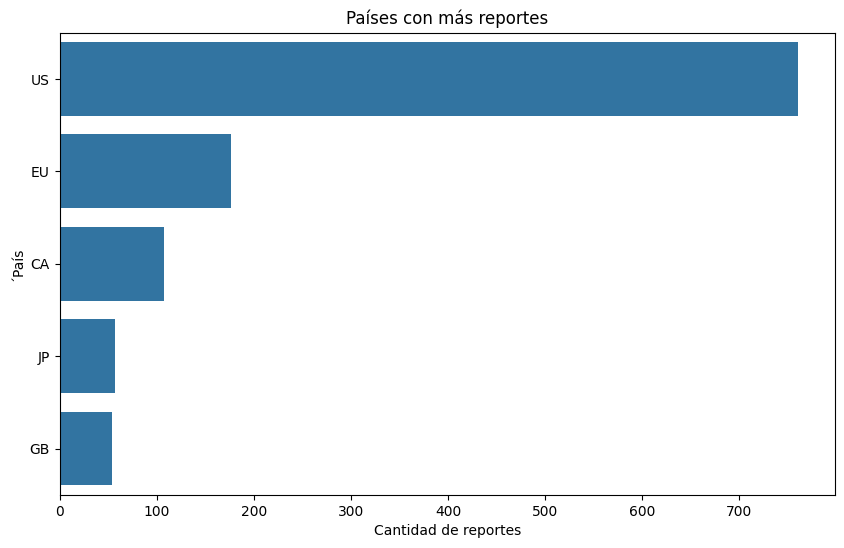

In [38]:
### Contar directamente desde country
top_paises = df2['country'].value_counts().head(5)

### Gráfico
plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=top_paises.values,
    y=top_paises.index
)

### Título
plt.title("Países con más reportes")
plt.xlabel("Cantidad de reportes")
plt.ylabel("´País")


Se observa que los reportes de eventos adversos se concentran principalmente en un número reducido de países, destacando especialmente Estados Unidos y la Unión Europea.
Existe un conjunto amplio de paises que presentan pocos reportes los cuales fueron agrupados en **otros**

Este comportamiento sugiere la existencia de un sesgo geográfico, donde los países con sistemas de salud más desarrollados o con mejores mecanismos de farmacovigilancia tienden a generar una mayor cantidad de reportes.

**¿Qué medicamentos presentan mayor cantidad de reportes?**

Queremos generar un analisis en base a que farmaco presenta con mayor frecuencia los reportes

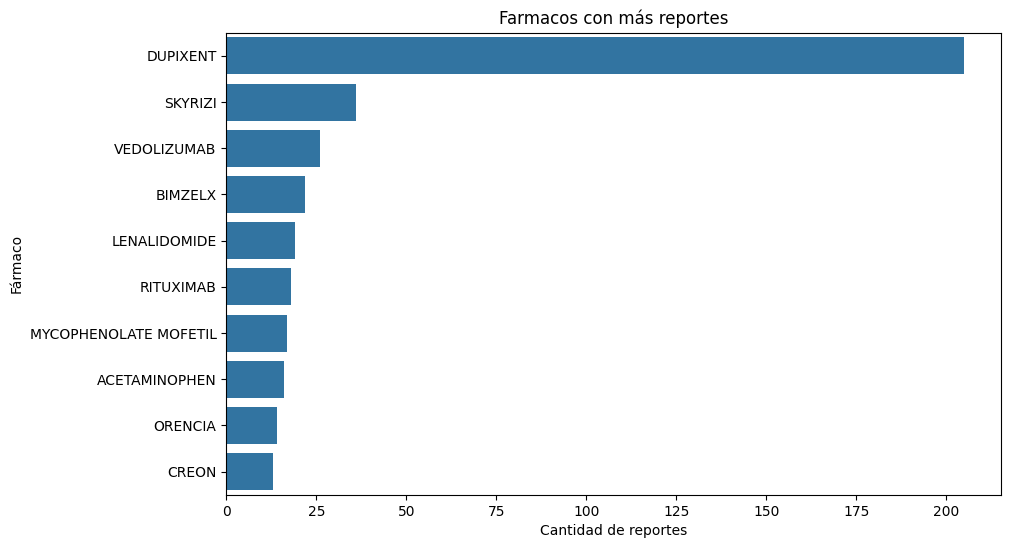

In [23]:
### Contamos la frecuencia de cada medicamento
top_drugs = df2['drug'].value_counts().head(10)

### Gráfico horizontal
plt.figure(figsize=(10,6))
ax = sns.barplot(x=top_drugs.values, y=top_drugs.index)

### Personalización
plt.title("Farmacos con más reportes")
plt.xlabel("Cantidad de reportes")
plt.ylabel("Fármaco")

plt.show()

Los medicamentos con más reportes no necesariamente son más peligrosos, sino que pueden ser más utilizados.


**¿Que es dupixent?**
Es un medicamento inyectable que puede ayudar a tratar la dermatitis atópica, el asma y la rinosinusitis crónica con pólipos nasales.

**¿Cuáles son los efectos adversos más frecuentes asociados a DUPIXENT?**

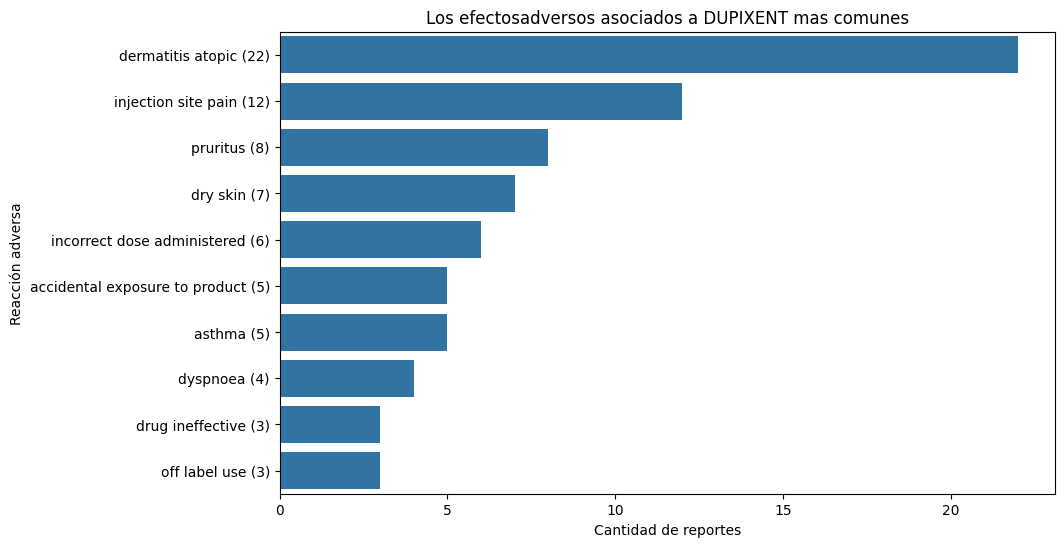

In [24]:
### Filtramos solo los registros de DUPIXENT
dupixent_df = df2[df2['drug'] == 'DUPIXENT']

### Contamos las reacciones adversas
top_reacciones_dupixent = dupixent_df['reaction'].value_counts().head(10)

### Creamos etiquetas con cantidad
labels = [f"{reaction} ({count})" for reaction, count in zip(top_reacciones_dupixent.index, top_reacciones_dupixent.values)]

### Gráfico
plt.figure(figsize=(10,6))
sns.barplot(x=top_reacciones_dupixent.values, y=labels)

### Títulos
plt.title("Los efectosadversos asociados a DUPIXENT mas comunes")
plt.xlabel("Cantidad de reportes")
plt.ylabel("Reacción adversa")

plt.show()

**¿Para que nos sirve?**

Es el farmaco que tiene mas reportes

Analizarlo de forma individual

Identifica sus efectos adversos más comunes

Es útil para farmacovigilancia

Sirve como base para evaluar riesgo en etapas posteriores

**Veamos ahora los efectos adversos mas comunes dentro del data**

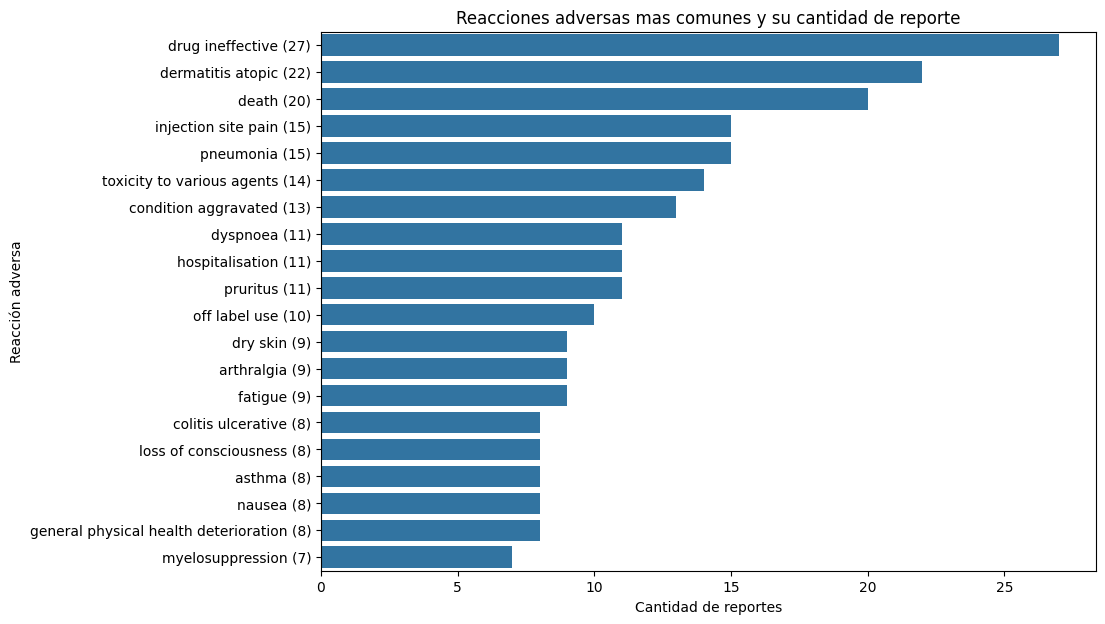

In [25]:
### Contamos las reacciones
top_20_reacciones = df2['reaction'].value_counts().head(20)

### Creamos etiquetas combinadas: "reacción (cantidad)"
labels = [f"{reaction} ({count})" for reaction, count in zip(top_20_reacciones.index, top_20_reacciones.values)]

### Gráfico
plt.figure(figsize=(10,7))
sns.barplot(x=top_20_reacciones.values, y=labels)

### Títulos
plt.title("Reacciones adversas mas comunes y su cantidad de reporte")
plt.xlabel("Cantidad de reportes")
plt.ylabel("Reacción adversa")

plt.show()

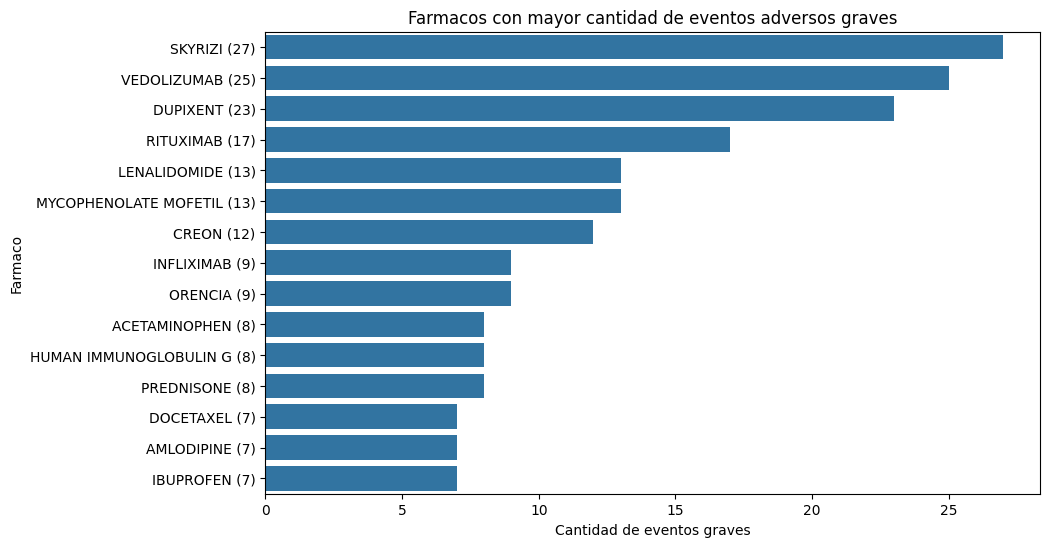

In [26]:
### Filtramos solo los eventos graves (serious = 1)
eventos_graves = df2[df2['serious'] == 1]


top_graves = eventos_graves['drug'].value_counts().head(15)


labels = [f"{drug} ({count})" for drug, count in zip(top_graves.index, top_graves.values)]

### Gráfico
plt.figure(figsize=(10,6))
sns.barplot(x=top_graves.values, y=labels)


plt.title("Farmacos con mayor cantidad de eventos adversos graves")
plt.xlabel("Cantidad de eventos graves")
plt.ylabel("Farmaco")

plt.show()

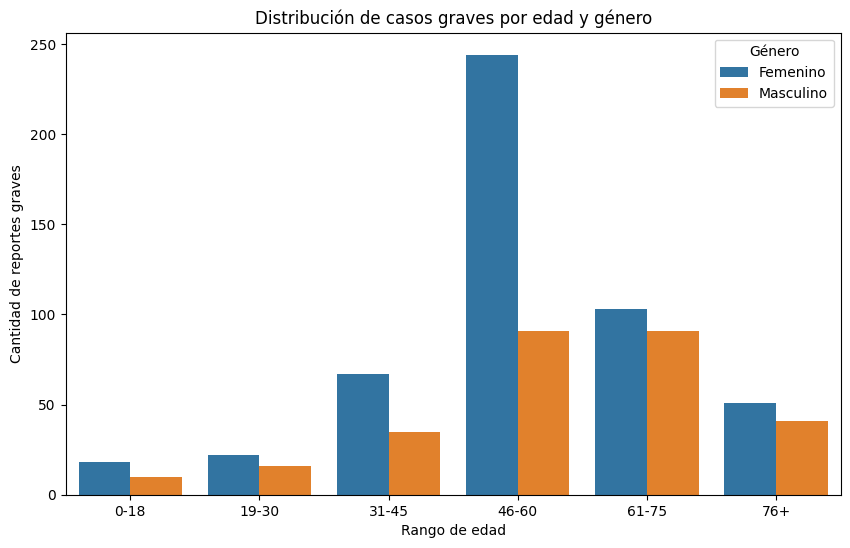

In [27]:
import numpy as np

### 0. Filtrar casos graves
df_graves = df2[df2['serious'] == 1].copy()

### 1. LIMPIAR edad (evita error TypeError)
df_graves = df_graves[df_graves['age'].notna()]
df_graves['age'] = pd.to_numeric(df_graves['age'], errors='coerce')
df_graves = df_graves[df_graves['age'].notna()]

### 2. Crear rangos de edad
df_graves['age_group'] = pd.cut(
    df_graves['age'],
    bins=[0, 18, 30, 45, 60, 75, 100],
    labels=['0-18', '19-30', '31-45', '46-60', '61-75', '76+'],
    include_lowest=True
)

### 3. Mapear género REAL de tu dataset
df_graves['gender_label'] = df_graves['gender'].map({
    1.0: 'Masculino',
    2.0: 'Femenino'
})

### 4. Agrupar (evita warning observed)
conteo_graves = df_graves.groupby(
    ['age_group', 'gender_label'],
    observed=True
).size().reset_index(name='count')

### 5. Gráfico
plt.figure(figsize=(10,6))
sns.barplot(
    data=conteo_graves,
    x='age_group',
    y='count',
    hue='gender_label'
)

plt.title("Distribución de casos graves por edad y género")
plt.xlabel("Rango de edad")
plt.ylabel("Cantidad de reportes graves")
plt.legend(title="Género")

plt.show()

**¿Se puede hacer un estudio para prevenirlos?**

Sí, orientado a farmacovigilancia y gestión de riesgo:

Qué harías con estos datos:

Detectar reacciones más frecuentes → priorizar vigilancia clínica

Identificar medicamentos con más eventos → revisar uso/seguimiento

Analizar grupos de riesgo (edad, género) → ajustar indicaciones

Revisar eventos graves → protocolos de alerta temprana

 El objetivo principal a nuestra vision es reducir incidencia y severidad, no eliminar al 100%.

# Fase 3: Preparacion de datos

## **Aplicando Encoder binario**

Como hay varias columnas que son categoricas y tienes demasiados valores como la columna "drug" y "reaction" haremos uso de binary encoding para no tener demasiadas filas

**Columna: drug**

In [28]:
df2['drug_name'] = df2['drug'] #Creamos una copia por que la columna se va a borrar
encoder_drug = ce.BinaryEncoder(cols=['drug'])
df2 = encoder_drug.fit_transform(df2)
print("Transformación completada con éxito")


Transformación completada con éxito


Realizamos encoders binarios debido a la gran cantidad de farmacos que se encuentran en el dataset es lo mismo para la variable reaction

In [29]:
#Diccionario de binary encoder

columnas_binarias = [c for c in df2.columns if 'drug_' in c and c != 'drug_name']

# Agrupamos por nombre para tener una fila por cada farmaco con su código
diccionario_drogas = df2[['drug_name'] + columnas_binarias].drop_duplicates()

# Lo ordenamos por nombre para que sea fácil de buscar
diccionario_drogas = diccionario_drogas.sort_values('drug_name').reset_index(drop=True)

# Guardamos este diccionario en un CSV aparte
diccionario_drogas.to_csv('diccionario_mapeo_farmacos.csv', index=False)

print("¡Diccionario creado con éxito!")
print(f"Total de drogas mapeadas: {len(diccionario_drogas)}")
display(diccionario_drogas.head(10))

¡Diccionario creado con éxito!
Total de drogas mapeadas: 463


,drug_name,drug_0,drug_1,drug_2,drug_3,drug_4,drug_5,drug_6,drug_7,drug_8
0,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,1,1,1,0,0,0,1,0,1
1,ABACAVIR SULFATE\LAMIVUDINE,0,1,1,0,1,0,0,0,1
2,ABILIFY MAINTENA,0,1,0,0,0,0,1,1,0
3,ABIRATERONE ACETATE,0,0,0,0,0,1,0,1,1
4,ABRILADA,1,0,0,1,0,1,0,1,1
5,ACCRUFER,0,1,0,0,0,0,0,0,0
6,ACETAMINOPHEN,0,0,0,0,1,0,1,1,1
7,ACOLTREMON,0,1,0,0,0,1,1,0,1
8,ACTEMRA,1,0,0,0,1,1,0,0,1
9,ADALIMUMAB,0,1,1,1,1,1,0,1,0


Se crea un diccionario para saber el valor binario de cada farmaco asi podremos tener una secuencia y una forma de clasificar bien estas variables

**Columna: Reaction**

In [30]:
# 1. Guardamos la copia para nosotros
df2['reaction_nombre'] = df2['reaction']

# 2. Aplicamos Binary Encoding
# Nota: Esto creará columnas del tipo reaction_0, reaction_1... reaction_9
encoder_rx = ce.BinaryEncoder(cols=['reaction'])
df2 = encoder_rx.fit_transform(df2)

print("Codificación de reacciones completada.")

Codificación de reacciones completada.


In [31]:
# Filtramos las nuevas columnas binarias de reacción
cols_rx_bin = [c for c in df2.columns if 'reaction_' in c and c != 'reaction_nombre']

# Creamos el mapa de traducción
diccionario_rx = df2[['reaction_nombre'] + cols_rx_bin].drop_duplicates()
diccionario_rx = diccionario_rx.sort_values('reaction_nombre').reset_index(drop=True)

# Guardamos el respaldo
diccionario_rx.to_csv('diccionario_mapeo_reacciones.csv', index=False)

print(f"Diccionario de reacciones creado con {len(diccionario_rx)} términos.")
display(diccionario_rx.head(5))

Diccionario de reacciones creado con 628 términos.


,reaction_nombre,reaction_0,reaction_1,reaction_2,reaction_3,reaction_4,reaction_5,reaction_6,reaction_7,reaction_8,reaction_9
0,abdominal discomfort,0,0,1,1,1,0,1,1,0,1
1,abdominal operation,1,0,0,0,1,1,1,0,0,0
2,abdominal pain,0,0,0,0,0,0,0,0,0,1
3,abdominal pain upper,0,1,0,0,0,1,1,1,0,0
4,abnormal sensation in eye,0,0,1,0,1,1,0,0,1,1


Normalizaremos las variables categoricas que estan codificadas con 1 y 2, lo cambiaremos a 0 y 1 para clasificacion binaria

En casi todas las variables de resultado de la FDA (death, disabling, hospitalization, etc.):

1 = Sí (El evento ocurrió).

2 = No (El evento no ocurrió).

Para gender 1 es masculino y 0 femenino cuando se haga el cambio

In [32]:
# Diccionario de corrección basado en el estándar FDA
# 1 se queda como 1 (Sí), y 2 pasa a ser 0 (No)
mapeo_binario = {1: 1, 2: 0}

# Aplicamos a todas las columnas de riesgo para que queden iguales
columnas = ['serious', 'death', 'life_threatening', 'hospitalization', 'disabling']

for col in columnas:
    df2[col] = df2[col].map(mapeo_binario)

# El género también suele venir como 1 (M) y 2 (F), mejor dejarlo en 1 y 0
df2['gender'] = df2['gender'].map({1: 1, 2: 0})

print("Ahora 1 siempre es Si/Masculino y 0 es No/Femenino")

Ahora 1 siempre es Si/Masculino y 0 es No/Femenino


## Lectura de diccionarios de binarios generados

In [33]:

#diccionario_drug = pd.read_csv('/content/drive/MyDrive/Evaluacion 1 Kevin/Copia de diccionario_encoder_farmacos.csv')
#diccionario_reactioon = pd.read_csv('/content/drive/MyDrive/Evaluacion 1 Kevin/Copia de diccionario_mapeo_reacciones.csv')


In [34]:

#diccionario_drug.head(500)

In [35]:

#diccionario_reactioon.head(700)

Solo para casos en que se quiera ver en colab el diccionario de los binarios, en github puede descargarse el csv

## **Variables a eliminar**

Variables a eliminar:


*   report_id: Solo son identificadores unicos

*   country: el factor demografico puede generarnos overfitting ya que la mayoria se concentra en Estados Unidos

*   report_type: No necesito saber el tipo de informe para el entramiento del modelo

*   occur_country: el factor demografico puede generarnos overfitting ya que la mayoria se concentra en Estados Unidos
*   receive_date: no lo necesitamos a menos que hagamos predicciones a partir del tiempo el cual no sera el caso

*   age_unit: debido que tambien tenia una gran cantidad de nulos esta columna nos servia para estandarizar pero despues de la imputacion llega a ser un riesgo




In [36]:
df_model = df2.drop(columns=['age_unit', 'receive_date', 'country',
                            'occur_country', 'report_type', 'report_id'], errors='ignore')

In [37]:
df_model.head()

,serious,death,life_threatening,hospitalization,disabling,age,gender,weight,drug_0,drug_1,drug_2,drug_3,drug_4,drug_5,drug_6,drug_7,drug_8,reaction_0,reaction_1,reaction_2,reaction_3,reaction_4,reaction_5,reaction_6,reaction_7,reaction_8,reaction_9,drug_name,reaction_nombre
0,0,0,0,0,0,42.000,1,71.91,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,DUPIXENT,abdominal pain
1,1,1,0,1,0,51.000,1,74.99,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,METHOTREXATE,toxicity to various agents
2,0,0,0,0,0,49.062,0,74.30,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,1,PEPCID COMPLETE,exposure during pregnancy
3,1,0,0,0,0,62.000,0,78.76,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,PACLITAXEL,drug ineffective
4,1,0,0,0,0,53.763,0,75.89,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,DULOXETINE,drug interaction


# Mapas de correlacion y comparacion de los dataset

Hay que hacer un commit para los cambios de 1 y 2 a binario, agregacion de estandarizacion